# PCL Binary Classification — DeBERTa-v3-base
SemEval 2022 Task 4 Subtask 1: Patronising and Condescending Language Detection

**Architecture:** DeBERTa-v3-base → Attention Pooling → Multi-sample Dropout → 2-layer Head → Focal Loss

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import f1_score, classification_report

# === Config ===
CONFIG = {
    "model_name": "microsoft/deberta-v3-base",
    "max_length": 128,
    "batch_size": 16,
    "num_epochs": 5,
    "encoder_lr": 2e-5,
    "head_lr": 1e-3,
    "num_dropout_samples": 5,
    "dropout_rate": 0.1,
    "seed": 42,
}

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
import os
os.chdir("/content/NLP-CW")
print(os.getcwd())

# === Data Loading ===
TSV_PATH = "dontpatronizeme_pcl.tsv"
TRAIN_SPLIT = "practice splits/train_semeval_parids-labels.csv"
DEV_SPLIT = "practice splits/dev_semeval_parids-labels.csv"
TEST_PATH = "task4_test.tsv"


# Load main dataset
df = pd.read_csv(
    TSV_PATH, sep="\t", header=None,
    names=["par_id", "art_id", "keyword", "country_code", "text", "label"],
    quoting=3, skiprows=4,
)
df["binary_label"] = (df["label"] >= 2).astype(int)
df = df.dropna(subset=["text"])

# Apply train/dev splits
train_ids = pd.read_csv(TRAIN_SPLIT)
dev_ids = pd.read_csv(DEV_SPLIT)

train_df = df[df["par_id"].isin(train_ids["par_id"])].reset_index(drop=True)
dev_df = df[df["par_id"].isin(dev_ids["par_id"])].reset_index(drop=True)

# Load test set (no labels)
test_df = pd.read_csv(
    TEST_PATH, sep="\t", header=None,
    names=["par_id", "art_id", "keyword", "country_code", "text"],
    quoting=3,
)
test_df = test_df.dropna(subset=["text"])

n_no_pcl = (train_df["binary_label"] == 0).sum()
n_pcl = (train_df["binary_label"] == 1).sum()

print(f"Train: {len(train_df)} total | PCL: {n_pcl} | No PCL: {n_no_pcl} | Ratio: {n_no_pcl/n_pcl:.1f}:1")
print(f"Dev:   {len(dev_df)} total | PCL: {dev_df['binary_label'].sum()} | No PCL: {(dev_df['binary_label']==0).sum()}")
print(f"Test:  {len(test_df)} examples (no labels)")

/content/NLP-CW
Train: 8375 total | PCL: 794 | No PCL: 7581 | Ratio: 9.5:1
Dev:   2093 total | PCL: 199 | No PCL: 1894
Test:  3832 examples (no labels)


In [5]:
# === Dataset Class ===
class PCLDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
        }

In [6]:
# === Model Architecture ===

class AttentionPooling(nn.Module):
    """Learnable attention-weighted pooling over token representations."""

    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Linear(hidden_size, 1)

    def forward(self, hidden_states, attention_mask):
        scores = self.attention(hidden_states).squeeze(-1)  # (batch, seq_len)
        scores = scores.masked_fill(attention_mask == 0, float("-inf"))
        weights = torch.softmax(scores, dim=-1)  # (batch, seq_len)
        pooled = torch.bmm(weights.unsqueeze(1), hidden_states).squeeze(1)
        return pooled, weights


class PCLClassifier(nn.Module):
    """
    DeBERTa-v3-base with:
    - Attention pooling
    - Multi-sample dropout (K=5 during training)
    - Two-layer classification head
    """

    def __init__(self, model_name, num_labels=2, dropout_rate=0.1, num_dropout_samples=5):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        self.attention_pool = AttentionPooling(hidden_size)
        self.num_dropout_samples = num_dropout_samples
        self.dropouts = nn.ModuleList([nn.Dropout(dropout_rate) for _ in range(num_dropout_samples)])

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_labels),
        )

        self.last_attn_weights = None

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        hidden_states = outputs.last_hidden_state

        pooled, attn_weights = self.attention_pool(hidden_states, attention_mask)
        self.last_attn_weights = attn_weights.detach()

        if self.training:
            logits = torch.stack(
                [self.classifier(dropout(pooled)) for dropout in self.dropouts],
                dim=0,
            ).mean(dim=0)
        else:
            logits = self.classifier(self.dropouts[0](pooled))

        return logits

In [7]:
# === Focal Loss ===

class FocalLoss(nn.Module):
    """FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)"""

    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=-1)
        targets_one_hot = F.one_hot(targets, num_classes=logits.size(-1)).float()
        p_t = (probs * targets_one_hot).sum(dim=-1)
        focal_weight = (1 - p_t) ** self.gamma
        ce_loss = -torch.log(p_t + 1e-8)
        loss = focal_weight * ce_loss

        if self.alpha is not None:
            alpha_t = (self.alpha.to(targets.device) * targets_one_hot).sum(dim=-1)
            loss = alpha_t * loss

        return loss.mean()

In [8]:
# === Training & Evaluation ===

def evaluate(model, data_loader, device):
    """Evaluate model. Returns F1, predictions, and P(PCL) probabilities."""
    model.eval()
    all_preds, all_probs, all_labels = [], [], []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"]

            logits = model(input_ids, attention_mask)
            probs = torch.softmax(logits, dim=-1)[:, 1]
            preds = (probs > 0.5).long()

            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    f1 = f1_score(all_labels, all_preds, pos_label=1)
    return f1, np.array(all_preds), np.array(all_probs)


def train_model(model, train_loader, dev_loader, device, config, n_no_pcl, n_pcl):
    """Train with focal loss and per-epoch dev eval."""

    # No alpha — sampler handles class balance
    criterion = FocalLoss(alpha=None, gamma=2.0)

    # Separate learning rates
    encoder_params = list(model.encoder.parameters())
    head_params = list(model.attention_pool.parameters()) + list(model.classifier.parameters())

    optimizer = AdamW([
        {"params": encoder_params, "lr": config["encoder_lr"]},
        {"params": head_params, "lr": config["head_lr"]},
    ], weight_decay=0.01)

    total_steps = len(train_loader) * config["num_epochs"]
    warmup_steps = int(total_steps * 0.1)
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    # No gradual unfreezing — encoder trains from epoch 1

    best_f1 = 0.0
    best_model_state = None

    for epoch in range(config["num_epochs"]):
        model.train()
        total_loss = 0

        for batch_idx, batch in enumerate(train_loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()

            if batch_idx % 50 == 0:
                print(f"  Epoch {epoch+1}, Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}")

        avg_loss = total_loss / len(train_loader)
        dev_f1, _, _ = evaluate(model, dev_loader, device)
        print(f"Epoch {epoch+1}/{config['num_epochs']} — Train Loss: {avg_loss:.4f} — Dev F1: {dev_f1:.4f}")

        if dev_f1 > best_f1:
            best_f1 = dev_f1
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f"  *** New best model! F1 = {best_f1:.4f} ***")

    model.load_state_dict(best_model_state)
    return model, best_f1

In [9]:
# === Threshold Tuning ===

def find_optimal_threshold(probs, labels, thresholds=np.arange(0.1, 0.9, 0.01)):
    """Sweep thresholds to maximise F1 on the PCL class."""
    best_f1 = 0
    best_threshold = 0.5

    for t in thresholds:
        preds = (probs >= t).astype(int)
        f1 = f1_score(labels, preds, pos_label=1)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = t

    print(f"Optimal threshold: {best_threshold:.2f} (F1 = {best_f1:.4f})")
    print(f"Default 0.5 threshold F1: {f1_score(labels, (probs >= 0.5).astype(int), pos_label=1):.4f}")
    return best_threshold

In [10]:
# === Run Training ===
from torch.utils.data import WeightedRandomSampler

tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

train_dataset = PCLDataset(train_df["text"].tolist(), train_df["binary_label"].tolist(), tokenizer, CONFIG["max_length"])
dev_dataset = PCLDataset(dev_df["text"].tolist(), dev_df["binary_label"].tolist(), tokenizer, CONFIG["max_length"])

# Weighted sampler
train_labels = train_df["binary_label"].values
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
sample_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_labels),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], sampler=sampler)
dev_loader = DataLoader(dev_dataset, batch_size=CONFIG["batch_size"], shuffle=False)

# Apply HP search results
CONFIG["encoder_lr"] = 3e-5
CONFIG["head_lr"] = 1e-3
CONFIG["dropout_rate"] = 0.2

model = PCLClassifier(
    model_name=CONFIG["model_name"],
    num_labels=2,
    dropout_rate=CONFIG["dropout_rate"],
    num_dropout_samples=CONFIG["num_dropout_samples"],
).float().to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

model, best_f1 = train_model(model, train_loader, dev_loader, device, CONFIG, n_no_pcl, n_pcl)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Model parameters: 184,029,699
  Epoch 1, Batch 0/524, Loss: 0.1546
  Epoch 1, Batch 50/524, Loss: 0.1726
  Epoch 1, Batch 100/524, Loss: 0.1710
  Epoch 1, Batch 150/524, Loss: 0.1692
  Epoch 1, Batch 200/524, Loss: 0.1115
  Epoch 1, Batch 250/524, Loss: 0.1127
  Epoch 1, Batch 300/524, Loss: 0.0934
  Epoch 1, Batch 350/524, Loss: 0.1074
  Epoch 1, Batch 400/524, Loss: 0.1237
  Epoch 1, Batch 450/524, Loss: 0.0548
  Epoch 1, Batch 500/524, Loss: 0.0791
Epoch 1/5 — Train Loss: 0.1410 — Dev F1: 0.4310
  *** New best model! F1 = 0.4310 ***
  Epoch 2, Batch 0/524, Loss: 0.1424
  Epoch 2, Batch 50/524, Loss: 0.0967
  Epoch 2, Batch 100/524, Loss: 0.0391
  Epoch 2, Batch 150/524, Loss: 0.0612
  Epoch 2, Batch 200/524, Loss: 0.0213
  Epoch 2, Batch 250/524, Loss: 0.1117
  Epoch 2, Batch 300/524, Loss: 0.0747
  Epoch 2, Batch 350/524, Loss: 0.0501
  Epoch 2, Batch 400/524, Loss: 0.1397
  Epoch 2, Batch 450/524, Loss: 0.0741
  Epoch 2, Batch 500/524, Loss: 0.0120
Epoch 2/5 — Train Loss: 0.0749 —

In [11]:
import os
os.chdir("/content/NLP-CW")


In [12]:
# === Threshold Tuning + Save Predictions ===

# Get dev probabilities from best model
dev_f1, dev_preds_default, dev_probs = evaluate(model, dev_loader, device)
dev_labels = dev_df["binary_label"].values

print("=== Threshold Tuning ===")
optimal_threshold = find_optimal_threshold(dev_probs, dev_labels)

# Apply optimal threshold to dev
dev_preds_tuned = (dev_probs >= optimal_threshold).astype(int)
tuned_f1 = f1_score(dev_labels, dev_preds_tuned, pos_label=1)
print(f"\nDev F1 (threshold=0.5):  {dev_f1:.4f}")
print(f"Dev F1 (threshold={optimal_threshold:.2f}): {tuned_f1:.4f}")

print("\n=== Classification Report (Dev, Tuned Threshold) ===")
print(classification_report(dev_labels, dev_preds_tuned, target_names=["No PCL", "PCL"]))

# Save dev.txt
with open("dev.txt", "w") as f:
    for pred in dev_preds_tuned:
        f.write(f"{pred}\n")
print(f"Saved dev.txt ({len(dev_preds_tuned)} predictions)")

# === Test set predictions ===
test_dataset = PCLDataset(
    test_df["text"].tolist(),
    [0] * len(test_df),  # dummy labels
    tokenizer,
    CONFIG["max_length"],
)
test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False)

_, _, test_probs = evaluate(model, test_loader, device)
test_preds = (test_probs >= optimal_threshold).astype(int)

with open("test.txt", "w") as f:
    for pred in test_preds:
        f.write(f"{pred}\n")
print(f"Saved test.txt ({len(test_preds)} predictions)")

# Save model
torch.save(model.state_dict(), "best_model.pt")
print("Saved best_model.pt")

=== Threshold Tuning ===
Optimal threshold: 0.31 (F1 = 0.5626)
Default 0.5 threshold F1: 0.5520

Dev F1 (threshold=0.5):  0.5520
Dev F1 (threshold=0.31): 0.5626

=== Classification Report (Dev, Tuned Threshold) ===
              precision    recall  f1-score   support

      No PCL       0.96      0.93      0.95      1894
         PCL       0.50      0.64      0.56       199

    accuracy                           0.90      2093
   macro avg       0.73      0.79      0.75      2093
weighted avg       0.92      0.90      0.91      2093

Saved dev.txt (2093 predictions)
Saved test.txt (3832 predictions)
Saved best_model.pt


### Evaluation graphs

Optimal threshold: 0.31 (F1 = 0.5626)
Default 0.5 threshold F1: 0.5520


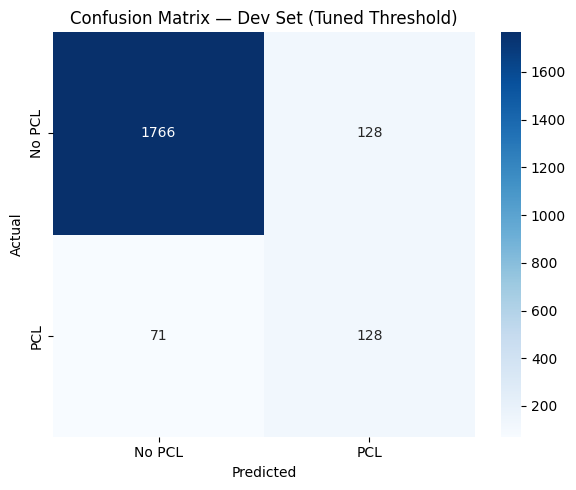


True Positives:  128  (PCL correctly identified)
False Negatives: 71  (PCL missed)
False Positives: 128  (No PCL incorrectly flagged as PCL)
True Negatives:  1766  (No PCL correctly identified)

Precision (PCL): 0.500
Recall (PCL):    0.643
F1 (PCL):        0.563


In [13]:
## Confusion matrix

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve, average_precision_score, classification_report
import textwrap

# === Get predictions and probabilities from best model ===
dev_f1, dev_preds_default, dev_probs = evaluate(model, dev_loader, device)
dev_labels = dev_df["binary_label"].values
dev_texts = dev_df["text"].values
dev_keywords = dev_df["keyword"].values

# Apply optimal threshold
optimal_threshold = find_optimal_threshold(dev_probs, dev_labels)
dev_preds = (dev_probs >= optimal_threshold).astype(int)

# === Confusion Matrix ===
cm = confusion_matrix(dev_labels, dev_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No PCL", "PCL"], yticklabels=["No PCL", "PCL"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Dev Set (Tuned Threshold)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Positives:  {tp}  (PCL correctly identified)")
print(f"False Negatives: {fn}  (PCL missed)")
print(f"False Positives: {fp}  (No PCL incorrectly flagged as PCL)")
print(f"True Negatives:  {tn}  (No PCL correctly identified)")
print(f"\nPrecision (PCL): {tp/(tp+fp):.3f}")
print(f"Recall (PCL):    {tp/(tp+fn):.3f}")
print(f"F1 (PCL):        {2*tp/(2*tp+fp+fn):.3f}")

In [14]:
### false negative and false positive examples

# === Categorise all dev examples ===
categories = []
for i in range(len(dev_labels)):
    if dev_labels[i] == 1 and dev_preds[i] == 1:
        categories.append("TP")
    elif dev_labels[i] == 1 and dev_preds[i] == 0:
        categories.append("FN")
    elif dev_labels[i] == 0 and dev_preds[i] == 1:
        categories.append("FP")
    else:
        categories.append("TN")

dev_df_analysis = dev_df.copy()
dev_df_analysis["prediction"] = dev_preds
dev_df_analysis["prob_pcl"] = dev_probs
dev_df_analysis["category"] = categories

# === Print example False Negatives (PCL the model missed) ===
fn_df = dev_df_analysis[dev_df_analysis["category"] == "FN"].sort_values("prob_pcl", ascending=False)

print("=" * 80)
print(f"FALSE NEGATIVES — PCL examples the model MISSED ({len(fn_df)} total)")
print("=" * 80)
for i, (_, row) in enumerate(fn_df.head(8).iterrows()):
    wrapped = textwrap.fill(row["text"], width=100)
    print(f"\n--- FN Example {i+1} | P(PCL) = {row['prob_pcl']:.3f} | keyword: {row['keyword']} ---")
    print(wrapped)

# === Print example False Positives (No PCL incorrectly flagged) ===
fp_df = dev_df_analysis[dev_df_analysis["category"] == "FP"].sort_values("prob_pcl", ascending=False)

print("\n" + "=" * 80)
print(f"FALSE POSITIVES — No PCL examples incorrectly flagged ({len(fp_df)} total)")
print("=" * 80)
for i, (_, row) in enumerate(fp_df.head(8).iterrows()):
    wrapped = textwrap.fill(row["text"], width=100)
    print(f"\n--- FP Example {i+1} | P(PCL) = {row['prob_pcl']:.3f} | keyword: {row['keyword']} ---")
    print(wrapped)

FALSE NEGATIVES — PCL examples the model MISSED (71 total)

--- FN Example 1 | P(PCL) = 0.255 | keyword: vulnerable ---
ICCCAD remains a strong advocate of local initiatives and supports the concept of Community Based
Adaptation ( CBA ) . Solutions developed at the local level have the best chance of being successful
since it is the poorest living in areas prone to storms , floods , and droughts who are most
vulnerable and best understand what needs to be done . This approach seeks to give these communities
a voice since it is powerlessness as much as location that makes these communities vulnerable to
climate change .

--- FN Example 2 | P(PCL) = 0.245 | keyword: homeless ---
"His present "" chambers "" may be quite humble , but Shiyani has the tiny space very neatly
organized and clean . Many people pass him by but do not manage to see him , because the space is
partially hidden behind trees , which gives him a relative privacy . "" There are many homeless
sleeping around the station

In [15]:
### Attention weight analysis

# === Categorise all dev examples ===
categories = []
for i in range(len(dev_labels)):
    if dev_labels[i] == 1 and dev_preds[i] == 1:
        categories.append("TP")
    elif dev_labels[i] == 1 and dev_preds[i] == 0:
        categories.append("FN")
    elif dev_labels[i] == 0 and dev_preds[i] == 1:
        categories.append("FP")
    else:
        categories.append("TN")

dev_df_analysis = dev_df.copy()
dev_df_analysis["prediction"] = dev_preds
dev_df_analysis["prob_pcl"] = dev_probs
dev_df_analysis["category"] = categories

# === Print example False Negatives (PCL the model missed) ===
fn_df = dev_df_analysis[dev_df_analysis["category"] == "FN"].sort_values("prob_pcl", ascending=False)

print("=" * 80)
print(f"FALSE NEGATIVES — PCL examples the model MISSED ({len(fn_df)} total)")
print("=" * 80)
for i, (_, row) in enumerate(fn_df.head(8).iterrows()):
    wrapped = textwrap.fill(row["text"], width=100)
    print(f"\n--- FN Example {i+1} | P(PCL) = {row['prob_pcl']:.3f} | keyword: {row['keyword']} ---")
    print(wrapped)

# === Print example False Positives (No PCL incorrectly flagged) ===
fp_df = dev_df_analysis[dev_df_analysis["category"] == "FP"].sort_values("prob_pcl", ascending=False)

print("\n" + "=" * 80)
print(f"FALSE POSITIVES — No PCL examples incorrectly flagged ({len(fp_df)} total)")
print("=" * 80)
for i, (_, row) in enumerate(fp_df.head(8).iterrows()):
    wrapped = textwrap.fill(row["text"], width=100)
    print(f"\n--- FP Example {i+1} | P(PCL) = {row['prob_pcl']:.3f} | keyword: {row['keyword']} ---")
    print(wrapped)

FALSE NEGATIVES — PCL examples the model MISSED (71 total)

--- FN Example 1 | P(PCL) = 0.255 | keyword: vulnerable ---
ICCCAD remains a strong advocate of local initiatives and supports the concept of Community Based
Adaptation ( CBA ) . Solutions developed at the local level have the best chance of being successful
since it is the poorest living in areas prone to storms , floods , and droughts who are most
vulnerable and best understand what needs to be done . This approach seeks to give these communities
a voice since it is powerlessness as much as location that makes these communities vulnerable to
climate change .

--- FN Example 2 | P(PCL) = 0.245 | keyword: homeless ---
"His present "" chambers "" may be quite humble , but Shiyani has the tiny space very neatly
organized and clean . Many people pass him by but do not manage to see him , because the space is
partially hidden behind trees , which gives him a relative privacy . "" There are many homeless
sleeping around the station

PER-KEYWORD F1 BREAKDOWN
Keyword                             F1   Total    PCL    FN    FP
----------------------------------------------------------------------
disabled                         0.581     194     14     5     8
homeless                         0.478     212     29    13    22
hopeless                         0.486     217     26     9    27
immigrant                        0.364     218      7     5     2
in-need                          0.691     226     33     5    20
migrant                          0.600     206      5     2     2
poor-families                    0.558     190     38    14    24
refugee                          0.621     188     13     4     7
vulnerable                       0.591     209     20     7    11
women                            0.538     233     14     7     5


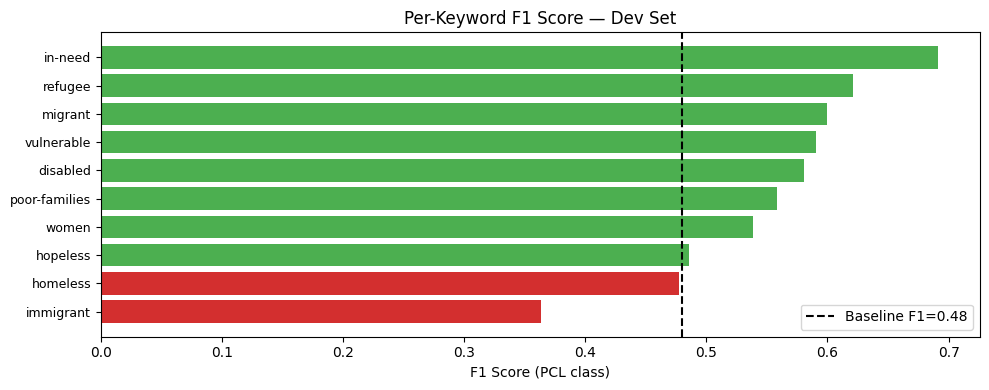

In [16]:
### Per-keyword F1 breakdown

print("=" * 70)
print("PER-KEYWORD F1 BREAKDOWN")
print("=" * 70)
print(f"{'Keyword':<30s}  {'F1':>6s}  {'Total':>6s}  {'PCL':>5s}  {'FN':>4s}  {'FP':>4s}")
print("-" * 70)

keyword_results = []
for keyword in sorted(dev_df_analysis["keyword"].unique()):
    subset = dev_df_analysis[dev_df_analysis["keyword"] == keyword]
    n_pcl = subset["binary_label"].sum()
    n_total = len(subset)
    n_fn = ((subset["binary_label"] == 1) & (subset["prediction"] == 0)).sum()
    n_fp = ((subset["binary_label"] == 0) & (subset["prediction"] == 1)).sum()

    if n_pcl > 0:
        kw_f1 = f1_score(subset["binary_label"], subset["prediction"], pos_label=1)
    else:
        kw_f1 = float('nan')

    keyword_results.append({"keyword": keyword, "f1": kw_f1, "total": n_total,
                            "pcl": n_pcl, "fn": n_fn, "fp": n_fp})
    print(f"{keyword:<30s}  {kw_f1:>6.3f}  {n_total:>6d}  {n_pcl:>5d}  {n_fn:>4d}  {n_fp:>4d}")

# Plot per-keyword F1
kw_df = pd.DataFrame(keyword_results).dropna(subset=["f1"]).sort_values("f1")
fig, ax = plt.subplots(figsize=(10, max(4, len(kw_df) * 0.4)))
colors = ['#d32f2f' if f1 < 0.48 else '#4caf50' for f1 in kw_df["f1"]]
ax.barh(range(len(kw_df)), kw_df["f1"], color=colors)
ax.set_yticks(range(len(kw_df)))
ax.set_yticklabels(kw_df["keyword"], fontsize=9)
ax.axvline(x=0.48, color="black", linestyle="--", label="Baseline F1=0.48")
ax.set_xlabel("F1 Score (PCL class)")
ax.set_title("Per-Keyword F1 Score — Dev Set")
ax.legend()
plt.tight_layout()
plt.savefig("per_keyword_f1.png", dpi=150, bbox_inches="tight")
plt.show()

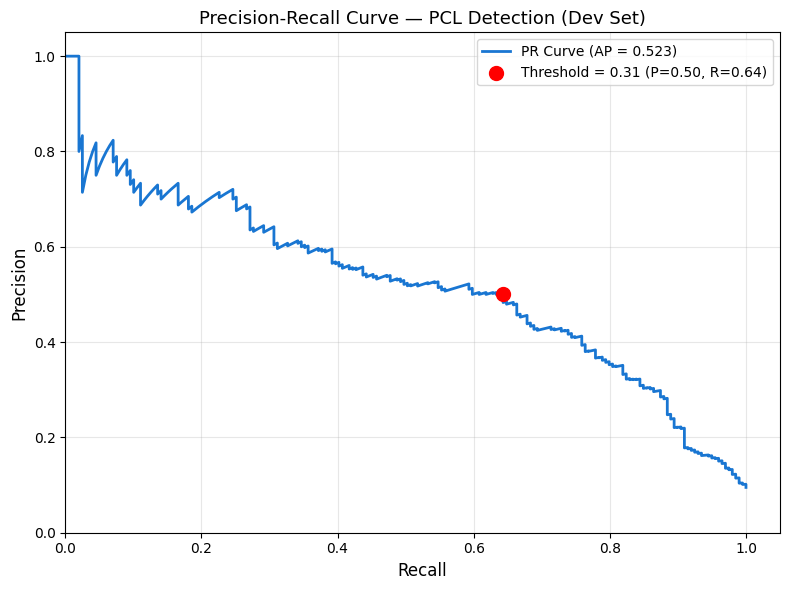

Average Precision (AP): 0.5227


In [17]:
# === Precision-Recall Curve ===
precision, recall, pr_thresholds = precision_recall_curve(dev_labels, dev_probs, pos_label=1)
ap = average_precision_score(dev_labels, dev_probs, pos_label=1)

# Find recall and precision at our optimal threshold
our_preds = (dev_probs >= optimal_threshold).astype(int)
our_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
our_recall = tp / (tp + fn) if (tp + fn) > 0 else 0

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall, precision, color='#1976d2', linewidth=2, label=f"PR Curve (AP = {ap:.3f})")
ax.scatter([our_recall], [our_precision], color='red', s=100, zorder=5,
           label=f"Threshold = {optimal_threshold:.2f} (P={our_precision:.2f}, R={our_recall:.2f})")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curve — PCL Detection (Dev Set)", fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim([0, 1.05])
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Average Precision (AP): {ap:.4f}")



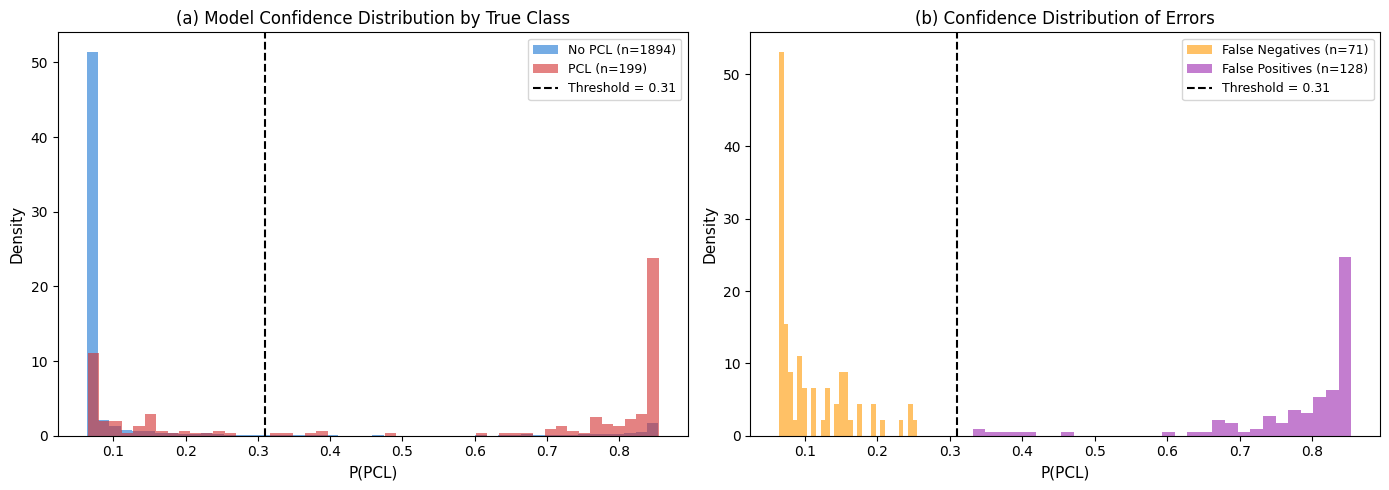

False Negatives — mean P(PCL): 0.109, median: 0.083
False Positives — mean P(PCL): 0.782, median: 0.829
Threshold: 0.31


In [18]:
# === Confidence Distribution ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel (a): Overlapping histograms
ax = axes[0]
ax.hist(dev_probs[dev_labels == 0], bins=50, alpha=0.6, label=f"No PCL (n={sum(dev_labels==0)})",
        color="#1976d2", density=True)
ax.hist(dev_probs[dev_labels == 1], bins=50, alpha=0.6, label=f"PCL (n={sum(dev_labels==1)})",
        color="#d32f2f", density=True)
ax.axvline(x=optimal_threshold, color="black", linestyle="--", linewidth=1.5,
           label=f"Threshold = {optimal_threshold:.2f}")
ax.set_xlabel("P(PCL)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("(a) Model Confidence Distribution by True Class", fontsize=12)
ax.legend(fontsize=9)

# Panel (b): Confidence for errors only
ax2 = axes[1]
fn_probs = dev_probs[(dev_labels == 1) & (dev_preds == 0)]
fp_probs = dev_probs[(dev_labels == 0) & (dev_preds == 1)]
ax2.hist(fn_probs, bins=30, alpha=0.6, label=f"False Negatives (n={len(fn_probs)})",
         color="#ff9800", density=True)
ax2.hist(fp_probs, bins=30, alpha=0.6, label=f"False Positives (n={len(fp_probs)})",
         color="#9c27b0", density=True)
ax2.axvline(x=optimal_threshold, color="black", linestyle="--", linewidth=1.5,
            label=f"Threshold = {optimal_threshold:.2f}")
ax2.set_xlabel("P(PCL)", fontsize=11)
ax2.set_ylabel("Density", fontsize=11)
ax2.set_title("(b) Confidence Distribution of Errors", fontsize=12)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("confidence_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Print summary stats
print(f"False Negatives — mean P(PCL): {fn_probs.mean():.3f}, median: {np.median(fn_probs):.3f}")
print(f"False Positives — mean P(PCL): {fp_probs.mean():.3f}, median: {np.median(fp_probs):.3f}")
print(f"Threshold: {optimal_threshold:.2f}")

ABLATION STUDY
                           Variant Dev F1 Change vs Full
      Full model (tuned threshold) 0.5626              —
Full model (default threshold=0.5) 0.5520        -0.0106
No weighted sampler (shuffle=True) 0.0000        -0.5626



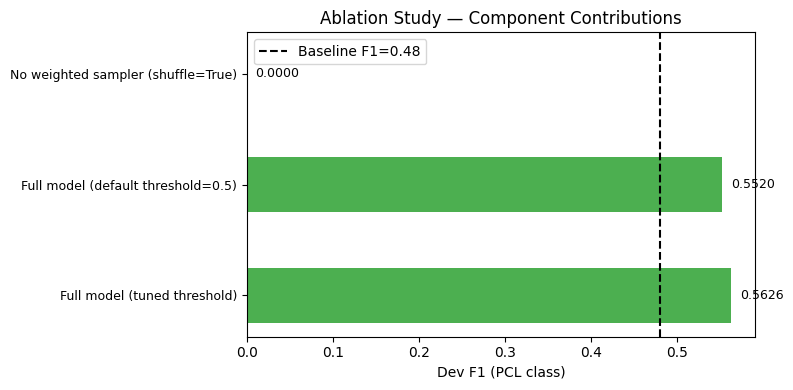

In [19]:
# === Ablation Study Summary ===
# Fill in the F1 values from your experiments
# You already have: full model F1, default threshold F1, and the 0.00 F1 from no sampler

ablation_data = {
    "Variant": [
        "Full model (tuned threshold)",
        "Full model (default threshold=0.5)",
        "No weighted sampler (shuffle=True)",
        # Add more rows if you ran additional experiments:
        # "No focal loss (standard CE)",
        # "No attention pooling ([CLS] only)",
    ],
    "Dev F1": [
        f"{f1_score(dev_labels, dev_preds, pos_label=1):.4f}",
        f"{f1_score(dev_labels, dev_preds_default, pos_label=1):.4f}",
        "0.0000",
        # Add values here
    ],
    "Change vs Full": [
        "—",
        f"{f1_score(dev_labels, dev_preds_default, pos_label=1) - f1_score(dev_labels, dev_preds, pos_label=1):+.4f}",
        f"{0.0 - f1_score(dev_labels, dev_preds, pos_label=1):+.4f}",
    ],
}

ablation_df = pd.DataFrame(ablation_data)
print("=" * 70)
print("ABLATION STUDY")
print("=" * 70)
print(ablation_df.to_string(index=False))
print()

# Plot ablation
fig, ax = plt.subplots(figsize=(8, 4))
f1_values = [float(v) for v in ablation_data["Dev F1"]]
colors = ['#4caf50' if v >= 0.48 else '#d32f2f' for v in f1_values]
bars = ax.barh(range(len(f1_values)), f1_values, color=colors, height=0.5)
ax.set_yticks(range(len(f1_values)))
ax.set_yticklabels(ablation_data["Variant"], fontsize=9)
ax.axvline(x=0.48, color="black", linestyle="--", label="Baseline F1=0.48")
ax.set_xlabel("Dev F1 (PCL class)")
ax.set_title("Ablation Study — Component Contributions")
ax.legend()

# Add value labels on bars
for bar, val in zip(bars, f1_values):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("ablation_study.png", dpi=150, bbox_inches="tight")
plt.show()